# Experiment: Baseline CNN on CIFAR-100 Binary Task

Standalone Colab-friendly notebook that trains the project's baseline CNN on a CIFAR-100 superclass-vs-rest binary task (`aquatic_mammals` vs. rest) and writes a full set of per-run artifacts under `tmp/baseline_cnn_notebook/`.

**Objective.** Reproduce the baseline training pipeline end-to-end in a single self-contained notebook so a fresh Colab session can train a model, evaluate it, and emit the same `{config.yaml, class_balance.json, history.json, metrics.json}` artifact contract used by `python -m training.train`.

**Done when.** A 2-epoch smoke run on a 1024-image stratified subset finishes, produces non-degenerate metrics (accuracy, precision, recall, F1, ROC-AUC) on the test split, the four artifact files exist on disk, and the diagnostic 2x2 figure renders.

**Plan.**
1. Setup: subprocess-based install fallback for `datasets`, `scikit-learn`, `pyyaml`, then imports and global seeding.
2. Load CIFAR-100 from Hugging Face (`uoft-cs/cifar100`) into NumPy arrays.
3. Build the binary task (`aquatic_mammals` coarse vs. rest) and print class counts.
4. Take a stratified 1024-image subset for the smoke run.
5. Inline reimplementation of `stratified_train_val_split`.
6. `tf.data` pipelines for train / val / test.
7. Inline `build_baseline_cnn` mirroring `models/baseline.py`.
8. Inline balanced class weights, compile + fit with `BinaryCrossentropy`, Adam, EarlyStopping.
9. Evaluate on test: accuracy / precision / recall / F1 / ROC-AUC + 2x2 confusion matrix.
10. 2x2 diagnostic figure (loss, accuracy, confusion matrix, sample predictions).
11. Persist `config.yaml`, `class_balance.json`, `history.json`, `metrics.json` under `tmp/baseline_cnn_notebook/<run_name>/`.

**Convention.** Per `notebooks/README.md`, this notebook does NOT import from local `data/`, `models/`, `training/`, or `evaluation/`. Everything is reimplemented inline so the file runs in a fresh Colab.


## 1. Setup

Install missing dependencies via `subprocess` (avoiding `%pip` magic so static type checkers do not flag the notebook). Then import, seed NumPy / TensorFlow / Python `random`, and define the global config dict that drives the run.


In [1]:
# Install dependencies on demand for a fresh Colab environment. We gate every install
# on a successful import to avoid re-resolving an already-working package set, which
# in particular protects the typing_extensions version that the local kernel needs.
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        target = pip_name or module_name
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", target]
        )


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("yaml", "pyyaml")
_ensure("matplotlib")


/Users/fgram-devai/Documents/Projects/Python/deepL-image-analysis/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import yaml
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("tensorflow:", tf.__version__)
print("numpy:     ", np.__version__)


tensorflow: 2.13.1
numpy:      1.24.3


In [3]:
# Single config dict mirroring configs/binary/fine/baseline_cnn_cow.yaml but tuned for a CPU smoke run.
CONFIG = {
    "architecture": "baseline_cnn",
    "run_name": "baseline_cnn_aquatic_mammals_smoke",
    "seed": SEED,
    "task": {
        "label_level": "coarse",
        "positive_label_names": ["aquatic_mammals"],
    },
    "validation": {"fraction": 0.2, "stratify": True},
    "class_imbalance": {"strategy": "class_weights"},
    "batch_size": 64,
    "shuffle_buffer": 1024,
    "dropout": 0.3,
    "epochs": 2,
    "learning_rate": 0.001,
    "early_stopping": {"monitor": "val_loss", "patience": 2},
    "output_dir": "tmp/baseline_cnn_notebook",
    "save_weights": False,
    "subset_size": 1024,
}

RUN_DIR = Path(CONFIG["output_dir"]) / CONFIG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("run dir:", RUN_DIR.resolve())


run dir: /Users/fgram-devai/Documents/Projects/Python/deepL-image-analysis/notebooks/tmp/baseline_cnn_notebook/baseline_cnn_aquatic_mammals_smoke


## 2. Load CIFAR-100 from Hugging Face

We pull both splits and convert the PIL images into `(N, 32, 32, 3) uint8` NumPy arrays. The first load downloads ~170 MB and caches under `~/.cache/huggingface/`.


In [4]:
ds = load_dataset("uoft-cs/cifar100")
train_split = ds["train"]
test_split = ds["test"]

fine_names = train_split.features["fine_label"].names
coarse_names = train_split.features["coarse_label"].names


def split_to_arrays(split):
    """Convert a HF split into (images uint8, fine int64, coarse int64) arrays."""
    images = np.stack(
        [np.asarray(row["img"].convert("RGB"), dtype=np.uint8) for row in split]
    )
    fine = np.asarray(split["fine_label"], dtype=np.int64)
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, fine, coarse


train_images, train_fine, train_coarse = split_to_arrays(train_split)
test_images, test_fine, test_coarse = split_to_arrays(test_split)

print("train images:", train_images.shape, train_images.dtype)
print("test  images:", test_images.shape, test_images.dtype)
print("coarse range:", int(train_coarse.min()), int(train_coarse.max()))


train images: (50000, 32, 32, 3) uint8
test  images: (10000, 32, 32, 3) uint8
coarse range: 0 19


## 3. Build the Binary Task

Reimplements the same `make_binary_labels` contract used by `data/tasks.py`: map the selected coarse-class name to its integer id, then label every row in `{0, 1}`.


In [5]:
def make_binary_labels(labels: np.ndarray, positive_ids) -> np.ndarray:
    """Return int64 {0, 1} labels where members of `positive_ids` are 1."""
    positive_set = {int(i) for i in positive_ids}
    if not positive_set:
        return np.zeros_like(labels, dtype=np.int64)
    mask = np.isin(labels, list(positive_set))
    return mask.astype(np.int64)


task_cfg = CONFIG["task"]
names_table = coarse_names if task_cfg["label_level"] == "coarse" else fine_names
positive_ids = [names_table.index(name) for name in task_cfg["positive_label_names"]]

source_labels_train = (
    train_coarse if task_cfg["label_level"] == "coarse" else train_fine
)
source_labels_test = (
    test_coarse if task_cfg["label_level"] == "coarse" else test_fine
)

y_train_full = make_binary_labels(source_labels_train, positive_ids)
y_test_full = make_binary_labels(source_labels_test, positive_ids)

print(
    "task:", task_cfg["label_level"], task_cfg["positive_label_names"],
    "-> positive_ids =", positive_ids,
)
print("train class counts:", dict(Counter(y_train_full.tolist())))
print("test  class counts:", dict(Counter(y_test_full.tolist())))


task: coarse ['aquatic_mammals'] -> positive_ids = [0]
train class counts: {0: 47500, 1: 2500}
test  class counts: {0: 9500, 1: 500}


## 4. Stratified Subset for the Smoke Run

Naive head slicing of CIFAR-100 can leave the rare positive class out of the smoke subset. We instead take a deterministic stratified subset (matching `training/train.py::_stratified_subset`).


In [6]:
def stratified_subset(images, labels, *, subset_size, seed):
    """Deterministic stratified subset over binary labels."""
    if subset_size is None or subset_size >= labels.shape[0]:
        return images, labels
    if subset_size < 2:
        raise ValueError("subset_size must be >= 2")
    rng = np.random.default_rng(seed)
    parts = []
    for cls in (0, 1):
        cls_idx = np.flatnonzero(labels == cls)
        if cls_idx.size == 0:
            continue
        n_cls = max(1, int(round(subset_size * cls_idx.size / labels.shape[0])))
        n_cls = min(n_cls, cls_idx.size)
        parts.append(rng.choice(cls_idx, size=n_cls, replace=False))
    selected = np.concatenate(parts)
    if selected.shape[0] > subset_size:
        selected = rng.choice(selected, size=subset_size, replace=False)
    elif selected.shape[0] < subset_size:
        remaining = np.setdiff1d(
            np.arange(labels.shape[0]), selected, assume_unique=False
        )
        extra = rng.choice(
            remaining,
            size=min(subset_size - selected.shape[0], remaining.shape[0]),
            replace=False,
        )
        selected = np.concatenate([selected, extra])
    rng.shuffle(selected)
    return images[selected], labels[selected]


subset_size = CONFIG["subset_size"]
train_images_sub, y_train_sub = stratified_subset(
    train_images, y_train_full, subset_size=subset_size, seed=SEED
)
test_images_sub, y_test_sub = stratified_subset(
    test_images, y_test_full, subset_size=subset_size, seed=SEED + 1
)
print("train subset:", train_images_sub.shape, dict(Counter(y_train_sub.tolist())))
print("test  subset:", test_images_sub.shape, dict(Counter(y_test_sub.tolist())))


train subset: (1024, 32, 32, 3) {0: 973, 1: 51}
test  subset: (1024, 32, 32, 3) {0: 973, 1: 51}


## 5. Stratified Train/Validation Split

Reimplements `training/splits.py::stratified_train_val_split`: shuffle per-class indices with a seeded RNG, peel off `val_fraction` per class, reshuffle the union so positives and negatives are interleaved.


In [7]:
def stratified_train_val_split(images, labels, *, val_fraction, seed):
    """Deterministic stratified train/val split for binary labels."""
    if not 0.0 < val_fraction < 1.0:
        raise ValueError(f"val_fraction must be in (0, 1); got {val_fraction}")
    labels = np.asarray(labels).reshape(-1)
    rng = np.random.default_rng(seed)
    train_parts: list[np.ndarray] = []
    val_parts: list[np.ndarray] = []
    for cls in (0, 1):
        cls_idx = np.flatnonzero(labels == cls)
        rng.shuffle(cls_idx)
        n_val = int(round(cls_idx.size * val_fraction))
        if cls_idx.size > 1:
            n_val = max(1, min(n_val, cls_idx.size - 1))
        val_parts.append(cls_idx[:n_val])
        train_parts.append(cls_idx[n_val:])
    train_idx = np.concatenate(train_parts)
    val_idx = np.concatenate(val_parts)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return images[train_idx], labels[train_idx], images[val_idx], labels[val_idx]


x_tr, y_tr, x_val, y_val = stratified_train_val_split(
    train_images_sub,
    y_train_sub,
    val_fraction=float(CONFIG["validation"]["fraction"]),
    seed=SEED,
)
print("train:", x_tr.shape, dict(Counter(y_tr.tolist())))
print("val:  ", x_val.shape, dict(Counter(y_val.tolist())))


train: (819, 32, 32, 3) {0: 778, 1: 41}
val:   (205, 32, 32, 3) {0: 195, 1: 10}


## 6. `tf.data` Pipelines

Mirrors `data.make_pipeline(view="image")`: cast to float32, normalize to `[0, 1]`, shuffle (train only) with a seeded buffer, batch, prefetch.


In [8]:
def make_pipeline(images, labels, *, batch_size, shuffle, shuffle_buffer=1024, seed=None):
    """Build a tf.data.Dataset that yields (float32 image in [0,1], int64 label)."""
    images_f32 = images.astype(np.float32, copy=False) / 255.0
    labels_i64 = labels.astype(np.int64, copy=False)
    ds = tf.data.Dataset.from_tensor_slices((images_f32, labels_i64))
    if shuffle:
        ds = ds.shuffle(
            buffer_size=shuffle_buffer,
            seed=seed,
            reshuffle_each_iteration=False,
        )
    ds = ds.batch(batch_size, drop_remainder=False)
    return ds.prefetch(tf.data.AUTOTUNE)


batch_size = int(CONFIG["batch_size"])
shuffle_buffer = int(CONFIG["shuffle_buffer"])
train_ds = make_pipeline(
    x_tr, y_tr,
    batch_size=batch_size, shuffle=True,
    shuffle_buffer=shuffle_buffer, seed=SEED,
)
val_ds = make_pipeline(x_val, y_val, batch_size=batch_size, shuffle=False)
test_ds = make_pipeline(
    test_images_sub, y_test_sub, batch_size=batch_size, shuffle=False
)

sample_x, sample_y = next(iter(train_ds))
print("batch image:", sample_x.shape, sample_x.dtype, "range:", float(sample_x.numpy().min()), float(sample_x.numpy().max()))
print("batch label:", sample_y.shape, sample_y.dtype)


batch image: (64, 32, 32, 3) <dtype: 'float32'> range: 0.0 1.0
batch label: (64,) <dtype: 'int64'>


2026-06-19 13:37:45.350025: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-06-19 13:37:45.350078: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-06-19 13:37:45.350091: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2026-06-19 13:37:45.350143: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-19 13:37:45.350171: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 7. Baseline CNN Model

Inlined from `models/baseline.py`: two conv blocks (32, then 64 filters), max-pool + dropout after each, then a 128-unit dense head with sigmoid output. Returned uncompiled so we can compile it explicitly below.


In [9]:
keras = tf.keras
layers = tf.keras.layers


def build_baseline_cnn(input_shape=(32, 32, 3), dropout=0.3):
    """Compact 2-block CNN for binary image classification."""
    inputs = keras.Input(shape=input_shape, name="image")
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool2D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="baseline_cnn")


model = build_baseline_cnn(dropout=float(CONFIG["dropout"]))
model.summary()


Model: "baseline_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                      

## 8. Class Weights, Compile, Fit

Computes sklearn-balanced class weights for the train split (same contract as `training/class_weights.py`), compiles with `BinaryCrossentropy(from_logits=False)`, Adam, and trains with EarlyStopping monitoring `val_loss`.


In [10]:
def compute_balanced_class_weights(labels):
    """sklearn-balanced class weights for binary labels."""
    labels = np.asarray(labels).reshape(-1)
    classes = np.unique(labels)
    if classes.size < 2:
        return {0: 1.0, 1: 1.0}
    w = compute_class_weight(class_weight="balanced", classes=classes, y=labels)
    return {int(c): float(v) for c, v in zip(classes, w)}


strategy = CONFIG["class_imbalance"]["strategy"]
class_weight = (
    compute_balanced_class_weights(y_tr) if strategy == "class_weights" else None
)
print("class_weight:", class_weight)


class_weight: {0: 0.5263496143958869, 1: 9.987804878048781}


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=float(CONFIG["learning_rate"])
    ),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

es_cfg = CONFIG["early_stopping"]
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor=str(es_cfg["monitor"]),
        patience=int(es_cfg["patience"]),
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=int(CONFIG["epochs"]),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)
history_dict = {k: [float(v) for v in vs] for k, vs in history.history.items()}
print("history keys:", list(history_dict.keys()))


Epoch 1/2


2026-06-19 13:38:22.065097: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13/13 - 1s - loss: 0.6899 - accuracy: 0.6190 - val_loss: 0.4127 - val_accuracy: 0.9561 - 780ms/epoch - 60ms/step
Epoch 2/2


2026-06-19 13:38:22.557164: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13/13 - 0s - loss: 0.5682 - accuracy: 0.7326 - val_loss: 0.3763 - val_accuracy: 0.8878 - 101ms/epoch - 8ms/step
history keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']


## 9. Evaluate on the Test Split

Predict probabilities, threshold at 0.5, and compute the same metric block emitted by `evaluation/metrics.py`. ROC-AUC falls back to `nan` if only one class is present (it shouldn't be, on a stratified subset, but the contract still holds).


In [12]:
y_prob = model.predict(test_ds, verbose=0).reshape(-1)
y_pred = (y_prob >= 0.5).astype(np.int64)
y_true = y_test_sub.astype(np.int64).reshape(-1)

try:
    roc_auc = float(roc_auc_score(y_true, y_prob))
except ValueError:
    roc_auc = float("nan")

metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "precision": float(precision_score(y_true, y_pred, zero_division=0)),
    "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    "roc_auc": roc_auc,
}
cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).astype(np.int64)
metrics["confusion_matrix"] = cm.tolist()
metrics["class_counts"] = {
    "0": int((y_true == 0).sum()),
    "1": int((y_true == 1).sum()),
}

for k in ("accuracy", "precision", "recall", "f1", "roc_auc"):
    print(f"{k:>9s}: {metrics[k]:.4f}")
print("confusion_matrix:")
print(cm)


 accuracy: 0.8730
precision: 0.1565
   recall: 0.3529
       f1: 0.2169
  roc_auc: 0.7212
confusion_matrix:
[[876  97]
 [ 33  18]]


2026-06-19 13:38:32.910722: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


## 10. Diagnostic Figure

A single 2x2 figure: loss curves, accuracy curves, confusion-matrix heatmap, and a small grid of test predictions with their (`y_true`, `y_prob`) labels. Keeps the visual budget tight.


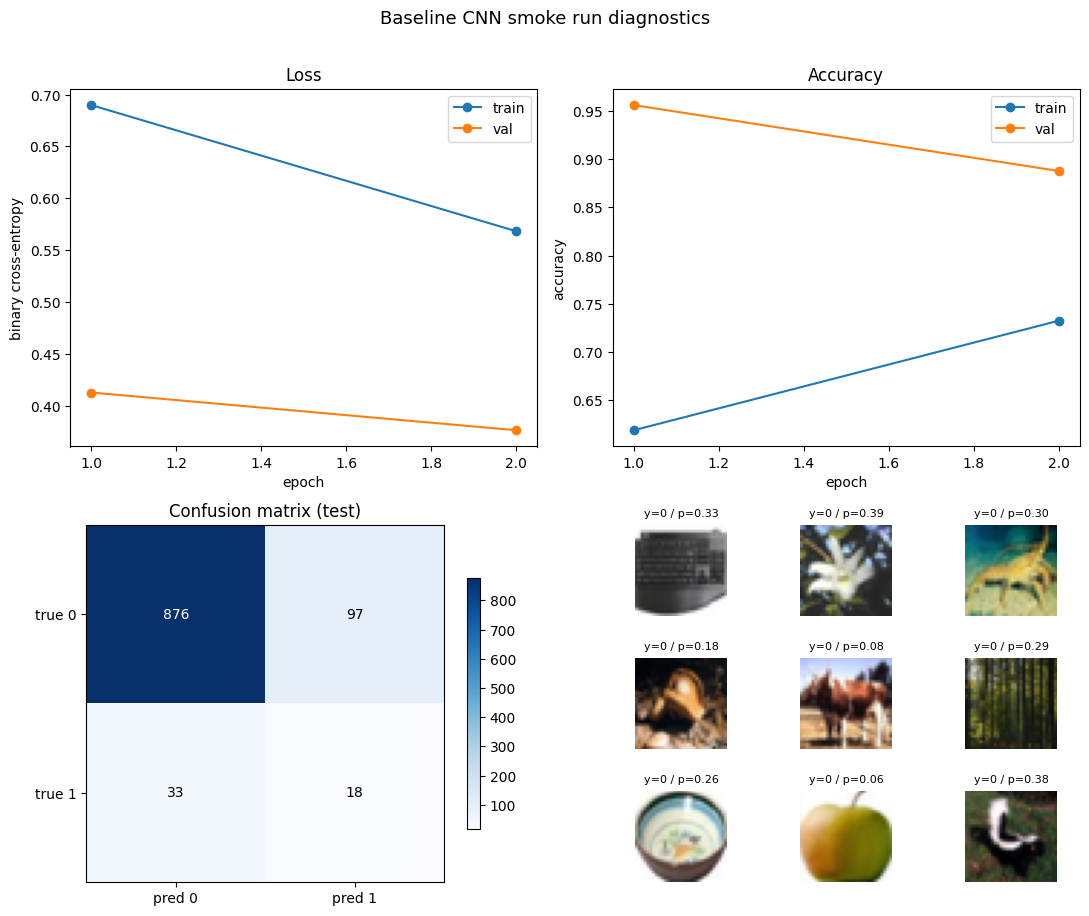

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# (0, 0) loss curves
epochs_axis = np.arange(1, len(history_dict["loss"]) + 1)
axes[0, 0].plot(epochs_axis, history_dict["loss"], marker="o", label="train")
if "val_loss" in history_dict:
    axes[0, 0].plot(
        epochs_axis, history_dict["val_loss"], marker="o", label="val"
    )
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("binary cross-entropy")
axes[0, 0].legend()

# (0, 1) accuracy curves
axes[0, 1].plot(epochs_axis, history_dict["accuracy"], marker="o", label="train")
if "val_accuracy" in history_dict:
    axes[0, 1].plot(
        epochs_axis, history_dict["val_accuracy"], marker="o", label="val"
    )
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("accuracy")
axes[0, 1].legend()

# (1, 0) confusion matrix heatmap
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1], ["pred 0", "pred 1"])
axes[1, 0].set_yticks([0, 1], ["true 0", "true 1"])
for i in range(2):
    for j in range(2):
        axes[1, 0].text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )
axes[1, 0].set_title("Confusion matrix (test)")
fig.colorbar(im, ax=axes[1, 0], shrink=0.7)

# (1, 1) sample predictions grid via a nested 3x3 subgridspec.
from matplotlib.gridspec import GridSpecFromSubplotSpec

n_samples = 9
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(y_true.shape[0], size=n_samples, replace=False)

outer_subplotspec = axes[1, 1].get_subplotspec()
axes[1, 1].remove()
inner = GridSpecFromSubplotSpec(
    3, 3, subplot_spec=outer_subplotspec, wspace=0.2, hspace=0.45
)
for k, idx in enumerate(sample_idx):
    sub_ax = fig.add_subplot(inner[k // 3, k % 3])
    sub_ax.imshow(test_images_sub[int(idx)])
    sub_ax.set_title(
        f"y={int(y_true[idx])} / p={float(y_prob[idx]):.2f}",
        fontsize=8,
    )
    sub_ax.axis("off")
fig.suptitle("Baseline CNN smoke run diagnostics", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


## 11. Persist Artifacts

Writes `config.yaml`, `class_balance.json`, `history.json`, and `metrics.json` under `tmp/baseline_cnn_notebook/<run_name>/`, matching the artifact contract defined in the plan. A small assertion cell follows to confirm presence.


In [14]:
class_balance = {
    "train": {"0": int((y_tr == 0).sum()), "1": int((y_tr == 1).sum())},
    "val":   {"0": int((y_val == 0).sum()), "1": int((y_val == 1).sum())},
    "test":  {"0": int((y_true == 0).sum()), "1": int((y_true == 1).sum())},
}
(RUN_DIR / "class_balance.json").write_text(json.dumps(class_balance, indent=2))
(RUN_DIR / "history.json").write_text(json.dumps(history_dict, indent=2))
(RUN_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
(RUN_DIR / "config.yaml").write_text(yaml.safe_dump(CONFIG, sort_keys=False))

for p in sorted(RUN_DIR.iterdir()):
    print(f"  {p.name:24s} {p.stat().st_size:>8d} B")


  class_balance.json            131 B
  config.yaml                   447 B
  history.json                  274 B
  metrics.json                  303 B


In [15]:
# Artifact-contract validation: assert presence of every required file.
required = ["config.yaml", "class_balance.json", "history.json", "metrics.json"]
missing = [name for name in required if not (RUN_DIR / name).exists()]
assert not missing, f"missing artifacts: {missing}"

# Sanity-check the saved metrics round-trip and contain the required keys.
saved = json.loads((RUN_DIR / "metrics.json").read_text())
for key in (
    "accuracy", "precision", "recall", "f1", "roc_auc",
    "confusion_matrix", "class_counts",
):
    assert key in saved, key
print("artifact contract OK")


artifact contract OK


## Notes / Next Steps

- This notebook is a smoke run: 2 epochs on 1024 stratified images. Replace `subset_size` with `None` and `epochs` with 15 (matching `configs/binary/fine/baseline_cnn_cow.yaml`) for a full-CIFAR-100 run on a CUDA machine.
- For the fine-class flavor (`cattle` / `cow` vs. rest), swap `task.label_level` to `"fine"` and `task.positive_label_names` to `["cattle"]`. Positive rate drops from ~5% (coarse `aquatic_mammals`) to ~1%, so class weighting matters more.
- Architecture successors planned for later branches: a row-as-timestep sequential model (RNN / LSTM / BiLSTM), a CIFAR-scale ViT, and an ImageNet-transfer baseline. Each will reuse the same artifact contract so results can be aggregated across runs.
- The CLI equivalent of this notebook is `venv/bin/python -m training.train --config configs/binary/fine/baseline_cnn_cow.yaml`; it writes to `results/<run_name>/` instead of `tmp/`, with `history.csv` and optional `weights.h5` in addition to the four files above.
